In [22]:
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
df = pd.read_excel("Marketing_Funnel_Dataset_Task3.xlsx")

In [24]:
df.head()

,Lead_ID,Date,Marketing_Channel,Region,Ad_Spend,Final_Stage,Revenue
0,1,2025-03-23,Facebook Ads,North,375.94,Lead,0.0
1,2,2025-01-29,Google Ads,North,344.82,Lead,0.0
2,3,2025-03-17,LinkedIn,North,34.30,Lead,0.0
3,4,2025-01-30,Email,North,289.40,Qualified Lead,0.0
4,5,2025-02-27,Email,East,408.53,Lead,0.0


In [25]:
visitors = len(df)

leads = len(df[df['Final_Stage'].isin([
    'Qualified Lead',
    'Demo',
    'Proposal',
    'Customer'
])])

qualified = len(df[df['Final_Stage'].isin([
    'Demo',
    'Proposal',
    'Customer'
])])

opportunities = len(df[df['Final_Stage'].isin([
    'Proposal',
    'Customer'
])])

customers = len(df[df['Final_Stage'] == 'Customer'])

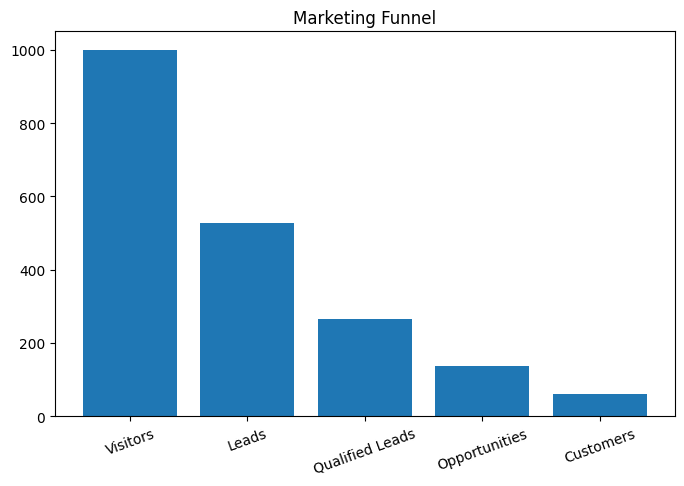

In [26]:
stages = [
    'Visitors',
    'Leads',
    'Qualified Leads',
    'Opportunities',
    'Customers'
]

values = [
    visitors,
    leads,
    qualified,
    opportunities,
    customers
]

plt.figure(figsize=(8,5))

plt.bar(stages, values)

plt.title("Marketing Funnel")

plt.xticks(rotation=20)

plt.show()

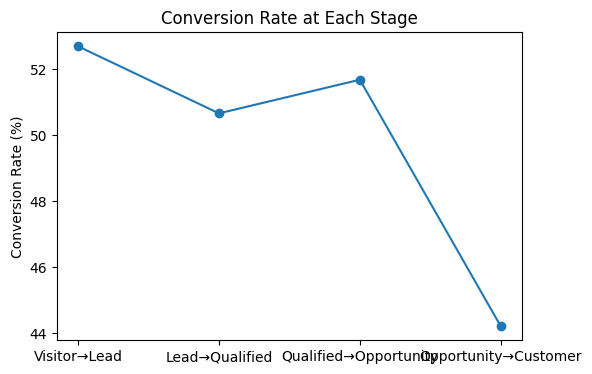

In [27]:
conversion_rates = []

for i in range(len(values)-1):
    rate = (values[i+1] / values[i]) * 100
    conversion_rates.append(rate)

conversion_stage = [
    'Visitor→Lead',
    'Lead→Qualified',
    'Qualified→Opportunity',
    'Opportunity→Customer'
]

plt.figure(figsize=(6,4))

plt.plot(conversion_stage, conversion_rates, marker='o')

plt.title("Conversion Rate at Each Stage")

plt.ylabel("Conversion Rate (%)")

plt.show()

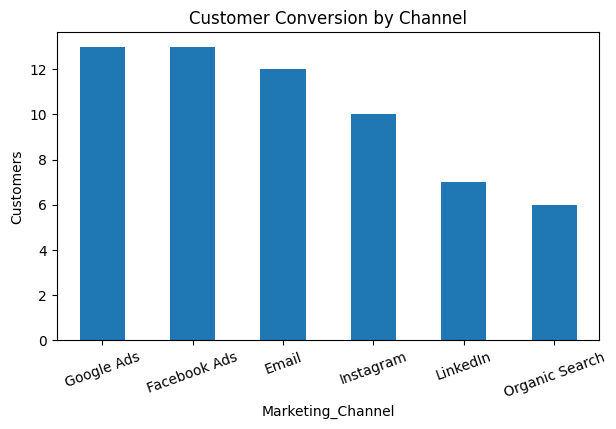

In [28]:
channel_customers = df[df['Final_Stage'] == 'Customer']

channel_performance = channel_customers['Marketing_Channel'].value_counts()

plt.figure(figsize=(7,4))

channel_performance.plot(kind='bar')

plt.title("Customer Conversion by Channel")

plt.ylabel("Customers")

plt.xticks(rotation=20)

plt.show()

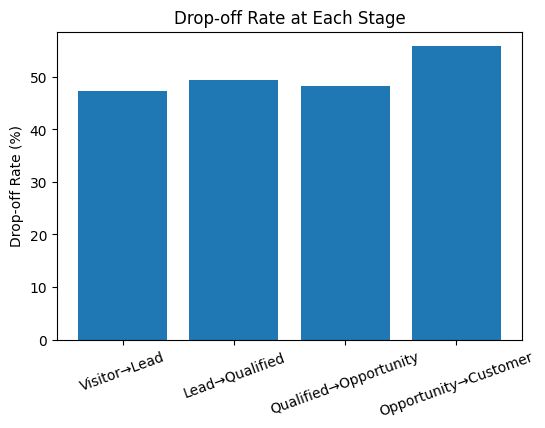

In [29]:
drop_rates = []

for i in range(len(values)-1):
    drop = ((values[i] - values[i+1]) / values[i]) * 100
    drop_rates.append(drop)

plt.figure(figsize=(6,4))

plt.bar(conversion_stage, drop_rates)

plt.title("Drop-off Rate at Each Stage")

plt.ylabel("Drop-off Rate (%)")

plt.xticks(rotation=20)

plt.show()

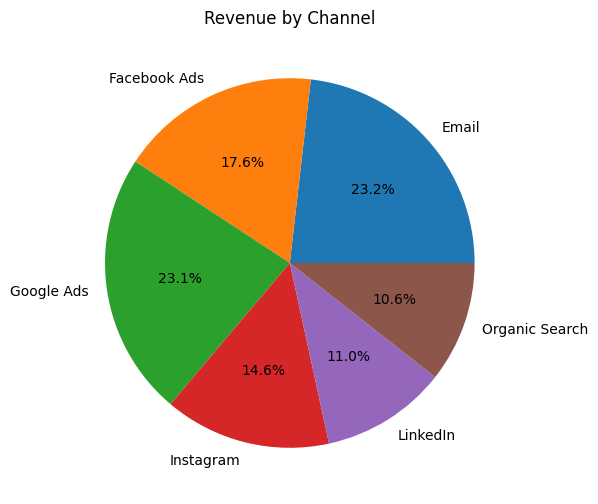

In [30]:
revenue_channel = df.groupby('Marketing_Channel')['Revenue'].sum()

plt.figure(figsize=(6,6))

plt.pie(
    revenue_channel,
    labels=revenue_channel.index,
    autopct='%1.1f%%'
)

plt.title("Revenue by Channel")

plt.show()

**Insights:**

* Large drop-off observed between Leads and Qualified Leads.
* Conversion rate decreases across each funnel stage.
* Customer acquisition reduces significantly in later stages.
* Some marketing channels contribute more revenue than others.
* Overall funnel performance indicates opportunities for conversion optimization.

**Recommendations:**

* Improve lead nurturing strategies to reduce early-stage drop-offs.
* Focus more on high-performing marketing channels.
* Optimize campaign targeting to attract quality leads.
* Increase customer engagement during middle funnel stages.
* Use data-driven marketing strategies to improve conversion rates and ROI.
